<a href="https://colab.research.google.com/github/SahilKumar001u/Retail-Seasonal-Demand-Forecasting-System/blob/main/Retail_Seasonal_demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
# 2. Upload Dataset

from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [ ]:
# 3. Load & Clean Data
df = pd.read_excel("Online Retail.xlsx")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[df['Quantity'] > 0]
df = df.dropna(subset=['Description'])
df['Sales'] = df['Quantity'] * df['UnitPrice']

In [ ]:
# 4. Category Selection
category = df['Description'].unique()[0]
print("Selected Category:", category)

Selected Category: WHITE HANGING HEART T-LIGHT HOLDER


In [ ]:
# 5. Category Aggregation (Weekly)
ts = (
    df[df['Description'] == category]
    .set_index('InvoiceDate')
    .resample('W')['Sales']
    .sum()
)
ts = ts.fillna(0)

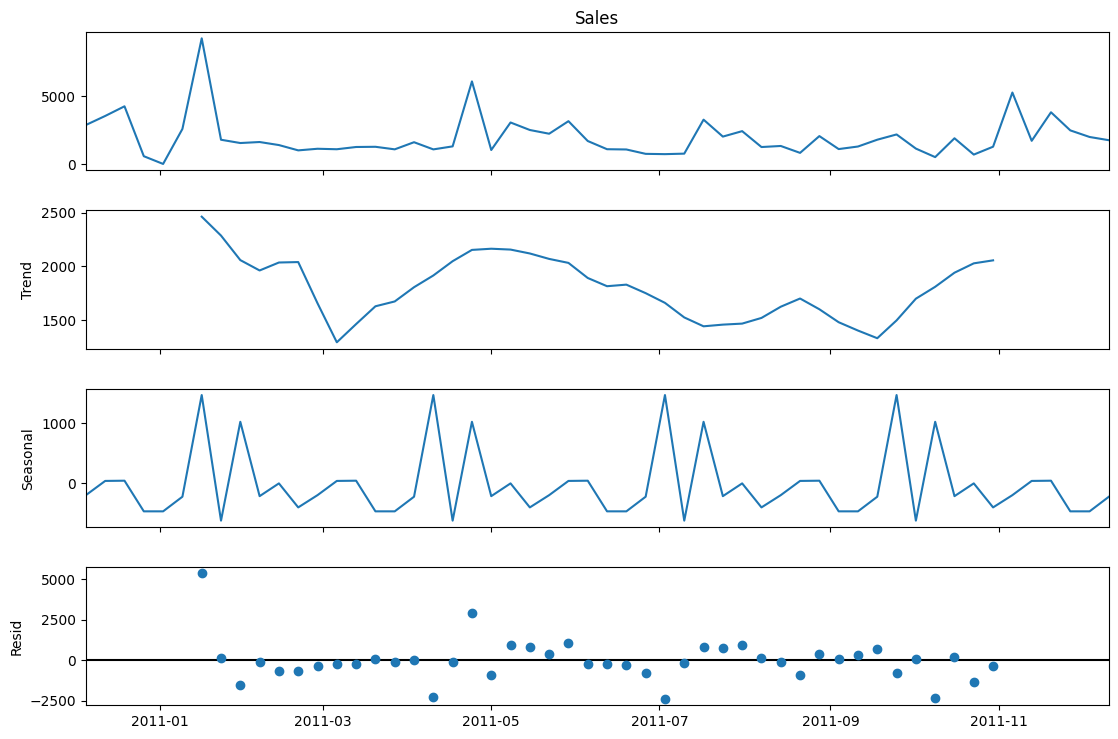

In [ ]:
# 6. Seasonal Decomposition
decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=12
)
fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

In [ ]:
# 8. Differencing
ts_diff = ts.diff().dropna()


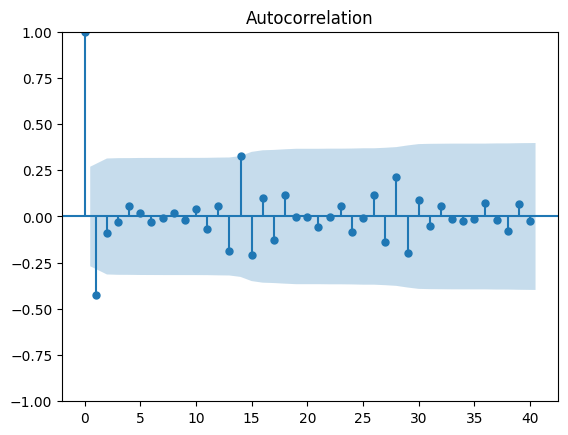

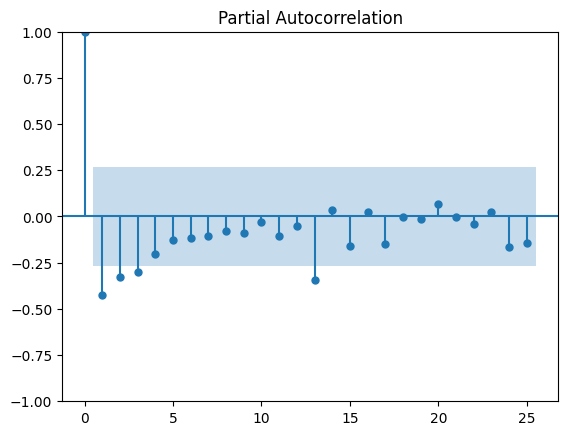

In [ ]:
# 9. ACF & PACF Plots

plot_acf(ts_diff, lags=40)
plt.show()

plot_pacf(ts_diff, lags=25)
plt.show()

In [ ]:
# 10. ARIMA MODEL
arima_model = ARIMA(ts, order=(2,1,2))
arima_result = arima_model.fit()

arima_forecast = arima_result.get_forecast(steps=12)
arima_pred = arima_forecast.predicted_mean
arima_conf = arima_forecast.conf_int()

In [ ]:
# 11. SARIMA MODEL

sarima_model = SARIMAX(
    ts,
    order=(2,1,2),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

sarima_forecast = sarima_result.get_forecast(steps=12)
sarima_pred = sarima_forecast.predicted_mean
sarima_conf = sarima_forecast.conf_int()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'



ARIMA sMAPE: 42.74534486384364
SARIMA sMAPE: 42.683274076861316


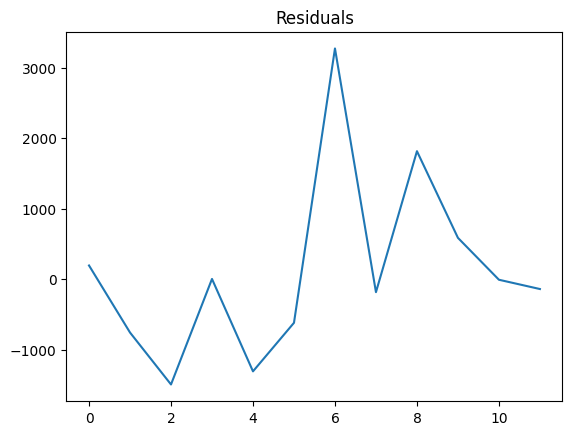

In [ ]:
# 12. sMAPE Metric
def smape(actual, forecast):

    actual = np.array(actual)
    forecast = np.array(forecast)

    denominator = np.abs(actual) + np.abs(forecast)

    mask = denominator != 0

    return np.mean(
        2 * np.abs(forecast[mask] - actual[mask]) /
        denominator[mask]
    ) * 100


test_actual = ts[-12:]

arima_error = smape(test_actual.values, arima_pred.values)
sarima_error = smape(test_actual.values, sarima_pred.values)
residuals = test_actual.values - arima_pred.values

print("\nARIMA sMAPE:", arima_error)
print("SARIMA sMAPE:", sarima_error)

plt.plot(residuals)
plt.title("Residuals")
plt.show()

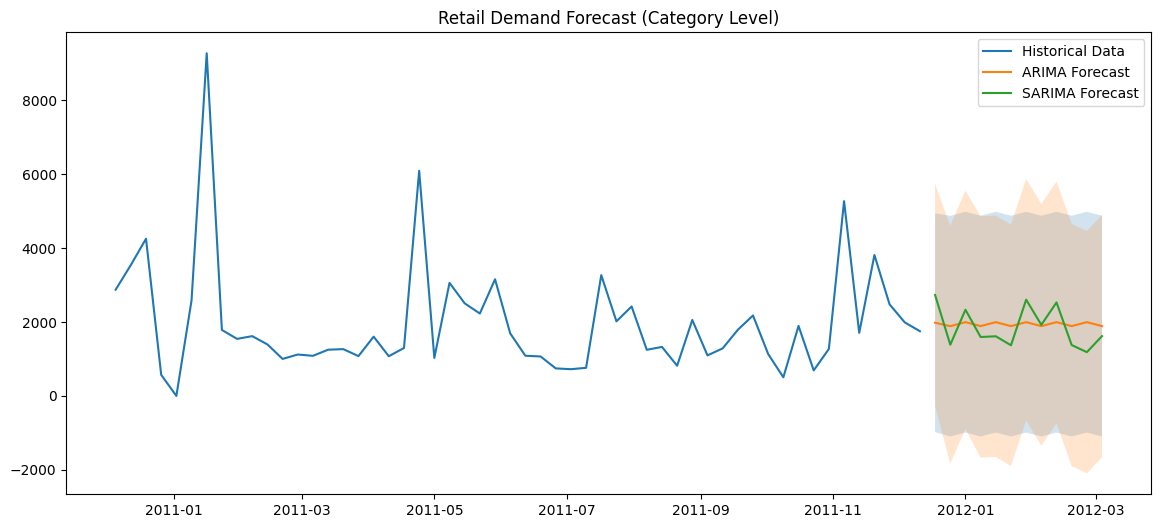

In [ ]:
# 13. Plot Forecast + Confidence Interval
plt.figure(figsize=(14,6))

plt.plot(ts, label="Historical Data")

plt.plot(arima_pred, label="ARIMA Forecast")
plt.fill_between(
    arima_conf.index,
    arima_conf.iloc[:,0],
    arima_conf.iloc[:,1],
    alpha=0.2
)

plt.plot(sarima_pred, label="SARIMA Forecast")
plt.fill_between(
    sarima_conf.index,
    sarima_conf.iloc[:,0],
    sarima_conf.iloc[:,1],
    alpha=0.2
)

plt.legend()
plt.title("Retail Demand Forecast (Category Level)")
plt.show()

In [ ]:
# 14. Print Forecast
print("\nARIMA Forecast")
print(arima_pred)

print("\nSARIMA Forecast")
print(sarima_pred)


ARIMA Forecast
2011-12-18    1979.470623
2011-12-25    1886.312977
2012-01-01    1994.746040
2012-01-08    1888.025284
2012-01-15    1994.937962
2012-01-22    1888.046815
2012-01-29    1994.940358
2012-02-05    1888.047102
2012-02-12    1994.940371
2012-02-19    1888.047122
2012-02-26    1994.940356
2012-03-04    1888.047138
Freq: W-SUN, Name: predicted_mean, dtype: float64

SARIMA Forecast
2011-12-18    2729.394517
2011-12-25    1384.353175
2012-01-01    2330.155646
2012-01-08    1592.998300
2012-01-15    1612.716408
2012-01-22    1369.082012
2012-01-29    2602.573850
2012-02-05    1922.454196
2012-02-12    2528.024319
2012-02-19    1375.384170
2012-02-26    1183.600052
2012-03-04    1617.931893
Freq: W-SUN, Name: predicted_mean, dtype: float64
